<a href="https://colab.research.google.com/github/Regi3051/BigData26_B_2411533004_RegiHeksaAnanda/blob/main/Praktikum1/BD_B_P01_2411533004_RegiHeksaAnanda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **J. Langkah Kerja Praktikum**

J-1. Verifikasi lingkungan kerja

In [31]:
import sys, platform, multiprocessing

print("Python   :", sys.version.split()[0])
print("OS       :", platform.platform())
print("CPU core :", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

Python   : 3.13.15
OS       : Linux-6.6.122+-x86_64-with-glibc2.39
CPU core : 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0


In [32]:
!free -h
!df -h /content
!java -version

               total        used        free      shared  buff/cache   available
Mem:            12Gi       3.8Gi       6.2Gi       3.2Mi       3.0Gi       8.8Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   22G   86G  21% /
[0.002s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.002s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


J-2. Menghubungkan Google Drive dan menyiapkan struktur folder

In [33]:
from google.colab import drive
drive.mount("/content/drive")
# ikuti dialog izin yang muncul

import os
DIR_KERJA = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/Kuliah/BigData/Praktikum1"

os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)

print(os.listdir(DIR_SIMPAN))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['yellow_tripdata_2023-01.parquet', 'agregasi_per_jam.csv', 'agregasi_per_jam.parquet', 'pengukuran_kinerja.csv', 'distribusi_per_jam.png', 'BD_B_P01_2411533004_RegiHeksaAnanda.ipynb']


J-3. Menyiapkan alat ukur waktu dan memori

In [34]:
import time, os, psutil

proses = psutil.Process(os.getpid())
catatan = [] # menyimpan hasil pengukuran untuk dibandingkan nanti

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    delta = rss_mb() - m0
    catatan.append({"langkah": label, "detik": round(detik, 2), "delta_rss_mb": round(delta, 1)})
    print(f"[{label}] {detik:.2f} s | RSS delta: {delta:+.1f} MB")
    return hasil

J-4. Mengunduh dataset dan inspeksi awal

In [35]:
import urllib.request

URL = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
       "yellow_tripdata_2023-01.parquet")
PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")

if not os.path.exists(PATH):
    ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))

print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

import pyarrow.parquet as pq

meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris :", f"{meta.num_rows:,}")
print("Jumlah kolom :", meta.num_columns)
print("Row group    :", meta.num_row_groups)
print("Nama kolom   :", pq.ParquetFile(PATH).schema.names)

Ukuran file: 45.5 MB
Jumlah baris : 3,066,766
Jumlah kolom : 19
Row group    : 1
Nama kolom   : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


J-5. Memuat data dan mengukur biaya memorinya

In [36]:
import pandas as pd

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh
import gc; gc.collect() # bebaskan memori sebelum percobaan kedua

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

df.head()
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2 # MB per kolom

[baca semua kolom] 2.76 s | RSS delta: +452.3 MB
Dimensi: (3066766, 19)
Memori 565.6 MB
[baca kolom terpilih] 0.87 s | RSS delta: +190.6 MB
Dimensi: (3066766, 8)
Memori 187.2 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 187.2 MB


,0
tpep_pickup_datetime,23.397568
payment_type,23.397568
tpep_dropoff_datetime,23.397568
passenger_count,23.397568
trip_distance,23.397568
tip_amount,23.397568
fare_amount,23.397568
total_amount,23.397568
Index,0.000126


In [37]:
sebelum = df.memory_usage(deep=True).sum() / 1024**2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"] = df["payment_type"].astype("int8").astype("category")

for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB (hemat {100*(1-sesudah/sebelum):.1f}%)")
df.dtypes

187.2 MB -> 119.9 MB (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


J-6. Pemeriksaan kualitas data dan pembersihan (veracity)

In [38]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())

print("\nNilai kosong per kolom: \n", df.isna().sum())

anomali = {
    "jarak <= 0": (df["trip_distance"] <= 0).sum(),
    "durasi <= 0": (df["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit": (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0": (df["total_amount"] <= 0).sum(),
}

for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    df["durasi_menit"].between(1, 180) &
    (df["total_amount"] > 0)
)

bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris (dibuang {len(df)-len(bersih):,})")

       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom: 
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 45,862 baris (1.50%)
durasi <= 0           : 1,121 baris (0.04%)
durasi > 180 menit    : 3,048 baris (0.10%)
total_amount <= 0     : 25,772 baris (0.84%)
3,066,766 baris -> 2,986,911 baris (dibuang 79,855)


J-7. Memproses file lebih besar dari memori dengan chunking

In [39]:
CSV = os.path.join(DIR_KERJA, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV) / 1024**2, 1), "MB")

[tulis CSV] 47.91 s | RSS delta: +0.6 MB
Parquet: 45.5 MB
CSV    : 226.2 MB


In [40]:
def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai = 0.0
    per_jam = {}

    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)

    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())

    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[agregasi chunking] 4.01 s | RSS delta: +7.0 MB
2,986,911 baris | rata-rata total_amount = 27.33


J-8. Pendekatan terdistribusi: PySpark local mode

In [41]:
!pip install -q pyspark==3.5.1
!java -version

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


In [42]:
# semua core mesin ini
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
    .appName("BD-P01")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate())

spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

Spark: 3.5.1


In [43]:
sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.col("tpep_dropoff_datetime").cast("timestamp").cast("double")
        - F.col("tpep_pickup_datetime").cast("timestamp").cast("double")) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

[spark count] 1.29 s | RSS delta: +0.0 MB
Jumlah baris: 3066766
+---+------+----------+----------+
|jam|jumlah|rata_jarak|rata_tar

In [44]:
sdf_bersih.createOrReplaceTempView("trips")

spark.sql("""
    SELECT payment_type,
           COUNT(*) AS jumlah,
           ROUND(AVG(total_amount), 2) AS rata_tarif,
           ROUND(AVG(tip_amount), 2) AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

hasil_spark.explain() # rencana eksekusi perhatikan Exchange / HashAggregate
spark.stop() # bebaskan sumber daya sebelum lanjut

+------------+-------+----------+--------+
|payment_type| jumlah|rata_tarif|rata_tip|
+------------+-------+----------+--------+
|           1|2385064|      28.1|    4.16|
|           2| 512987|     23.58|     0.0|
|           0|  64106|     29.82|    4.06|
|           4|  15570|     24.11|    0.02|
|           3|   9184|     22.63|     0.0|
+------------+-------+----------+--------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [jam#301 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(jam#301 ASC NULLS FIRST, 8), ENSURE_REQUIREMENTS, [plan_id=414]
      +- HashAggregate(keys=[jam#301], functions=[count(1), avg(trip_distance#221), avg(total_amount#233)])
         +- Exchange hashpartitioning(jam#301, 8), ENSURE_REQUIREMENTS, [plan_id=411]
            +- HashAggregate(keys=[jam#301], functions=[partial_count(1), partial_avg(trip_distance#221), partial_avg(total_amount#233)])
               +- Project [trip_distance#221, total_amount#233, hour(tpep_pickup_dat

J-9. Agregasi akhir dengan pandas dan penyimpanan artefak

In [45]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.860001,21.600000
1,1,57766,3.53,12.63,26.450001,21.200001
2,2,40445,3.28,12.07,25.059999,20.520000
3,3,26146,3.58,12.15,26.260000,21.000000
4,4,16618,4.79,13.52,31.719999,22.700001
5,5,16940,6.03,14.70,36.750000,22.040001
6,6,42300,4.80,14.49,30.629999,18.480000
7,7,84569,3.69,14.42,26.889999,18.480000
8,8,114064,3.08,14.33,25.209999,19.100000
9,9,127988,3.09,14.23,25.510000,19.250000


J-10. Visualisasi hasil

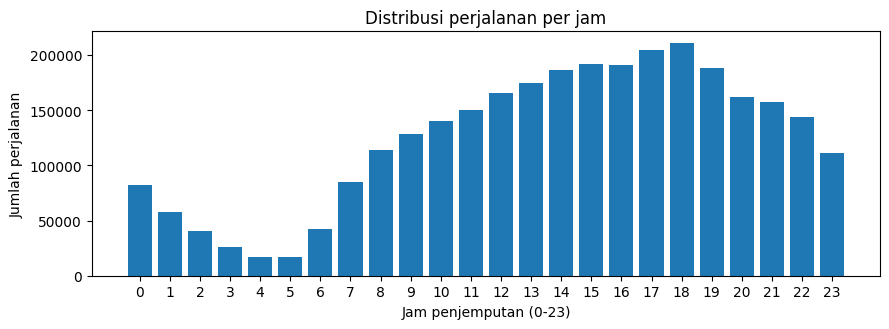

In [46]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0, 24))

fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()

# **O. Studi Kasus**

In [69]:
import matplotlib.pyplot as plt

bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

bersih["hari"] = bersih["tpep_pickup_datetime"].dt.day_name()
bersih["akhir_pekan"] = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5
bersih["tarif_per_menit"] = (bersih["total_amount"] / bersih["durasi_menit"]).round(3)

ringkas = (bersih
    .groupby(["akhir_pekan", "jam"])
    .agg(jumlah=("total_amount", "size"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif_per_menit=("tarif_per_menit", "mean"),
         rata_jarak=("trip_distance", "mean"))
    .round(2)
    .reset_index())

ringkas.to_csv(f"{DIR_SIMPAN}/penjadwalan_armada_oleh_operator_taksi.csv", index=False)
display(ringkas)

,akhir_pekan,jam,jumlah,rata_durasi,rata_tarif_per_menit,rata_jarak
0,False,0,35351,14.10,2.57,5.23
1,False,1,17516,13.04,2.66,4.78
2,False,2,9452,12.23,2.63,4.04
3,False,3,6238,12.87,2.72,4.69
4,False,4,6192,14.79,2.81,6.10
5,False,5,12462,14.63,2.82,5.93
6,False,6,35728,14.57,2.33,4.51
7,False,7,74157,14.66,2.07,3.44
8,False,8,98431,14.82,1.90,2.92
9,False,9,103263,15.03,1.90,3.01


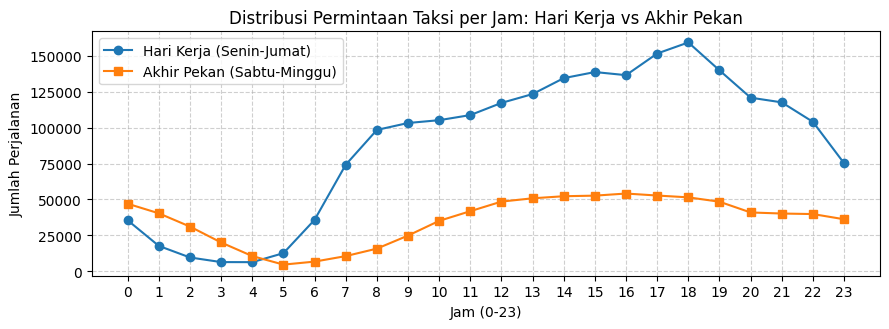

In [60]:
hari_kerja = ringkas[ringkas["akhir_pekan"] == False]
akhir_pekan = ringkas[ringkas["akhir_pekan"] == True]

fig, ax1 = plt.subplots(figsize=(9, 3.4))

ax1.plot(hari_kerja["jam"], hari_kerja["jumlah"], marker='o', label='Hari Kerja (Senin-Jumat)')
ax1.plot(akhir_pekan["jam"], akhir_pekan["jumlah"], marker='s', label='Akhir Pekan (Sabtu-Minggu)')
ax1.set_title("Distribusi Permintaan Taksi per Jam: Hari Kerja vs Akhir Pekan")
ax1.set_xlabel("Jam (0-23)")
ax1.set_ylabel("Jumlah Perjalanan")
ax1.set_xticks(range(0, 24))
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/Distribusi_Permintaan_Taksi_per_Jam(Hari_Kerja_vs_Akhir_Pekan).png", dpi=150)
plt.show()

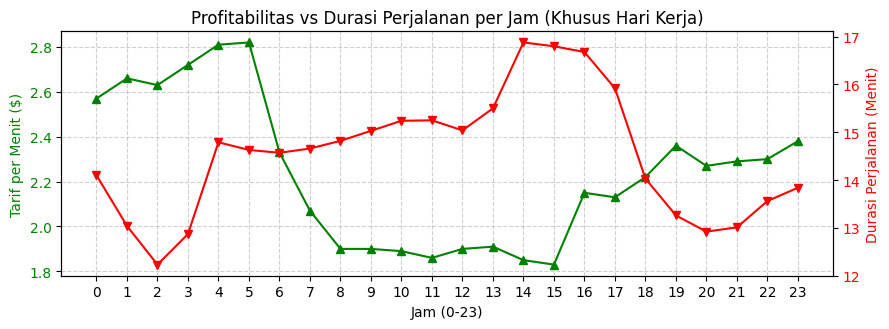

In [61]:
fig, ax2 = plt.subplots(figsize=(9, 3.4))

ax2.plot(hari_kerja["jam"], hari_kerja["rata_tarif_per_menit"], color='green', marker='^', label='Tarif per Menit ($)')
ax2.set_ylabel("Tarif per Menit ($)", color='green')
ax2.tick_params(axis='y', labelcolor='green')

ax3 = ax2.twinx()
ax3.plot(hari_kerja["jam"], hari_kerja["rata_durasi"], color='red', marker='v', label='Durasi (Menit)')
ax3.set_ylabel("Durasi Perjalanan (Menit)", color='red')
ax3.tick_params(axis='y', labelcolor='red')

ax2.set_title("Profitabilitas vs Durasi Perjalanan per Jam (Khusus Hari Kerja)")
ax2.set_xlabel("Jam (0-23)")
ax2.set_xticks(range(0, 24))
ax2.grid(True, linestyle='--', alpha=0.6)

fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/Profitabilitas_vs_Durasi_Perjalanan_per_Jam(Khusus_Hari_Kerja).png", dpi=150)
plt.show()

# **P. Latihan**

### latihan 1

In [49]:
import numpy as np
import time

top_5_distance = bersih.nlargest(5, 'trip_distance')
display(top_5_distance)

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount,durasi_menit,jam,hari,akhir_pekan,tarif_per_menit
1748933,2023-01-19 16:29:36,2023-01-19 18:46:01,1.0,96.70,1,350.000000,50.0,440.750000,136.416667,16,Thursday,False,3.231
526988,2023-01-07 04:29:56,2023-01-07 06:06:16,2.0,93.05,2,542.000000,0.0,564.049988,96.333333,4,Saturday,True,5.855
2402193,2023-01-26 04:55:45,2023-01-26 07:18:50,1.0,92.60,1,262.500000,20.0,312.799988,143.083333,4,Thursday,False,2.186
2902389,2023-01-31 07:04:24,2023-01-31 09:32:54,1.0,92.00,1,334.100006,10.0,368.149994,148.500000,7,Tuesday,False,2.479
927215,2023-01-11 14:23:55,2023-01-11 16:17:58,1.0,90.63,2,250.000000,0.0,272.299988,114.050000,14,Wednesday,False,2.388


Mengingat taksi kuning NYC umumnya melayani area urban yang padat, jarak tempuh mendekati 100 mil (sekitar 160 km) kemungkinan besar merupakan anomali argometer yang lupa dimatikan atau perjalanan antarkota yang jarang terjadi.

### Latihan 2

In [50]:

print("\n--- Latihan 2: Trade-off Chunksize ---")
ukuran_1 = 100_000
ukuran_2 = 1_000_000

baris_1, total_1, per_jam_1 = ukur(f"chunking {ukuran_1}", lambda: agregasi_bertahap(CSV, ukuran_chunk=ukuran_1))
baris_2, total_2, per_jam_2 = ukur(f"chunking {ukuran_2}", lambda: agregasi_bertahap(CSV, ukuran_chunk=ukuran_2))


--- Latihan 2: Trade-off Chunksize ---
[chunking 100000] 4.24 s | RSS delta: +4.5 MB
[chunking 1000000] 4.13 s | RSS delta: +12.7 MB


Chunksize kecil (100.000) menekan pemakaian memori (RAM stabil/kecil) namun waktu eksekusi melambat karena tingginya overhead iterasi I/O (membaca file berkali-kali). Sebaliknya, chunksize besar (1.000.000) memakan RAM secara agresif namun waktu eksekusi lebih singkat karena data yang diproses per batch CPU jauh lebih masif.

### Latihan 3

In [51]:
print("\n--- Latihan 3: Persentase Tip ---")
bersih['persen_tip'] = np.where(bersih['fare_amount'] > 0,
                                (bersih['tip_amount'] / bersih['fare_amount']) * 100,
                                0)

tip_per_payment = bersih.groupby('payment_type')['persen_tip'].mean().round(2).reset_index()
display(tip_per_payment)


--- Latihan 3: Persentase Tip ---


/tmp/ipykernel_1617/2100233871.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tip_per_payment = bersih.groupby('payment_type')['persen_tip'].mean().round(2).reset_index()


,payment_type,persen_tip
0,0,20.23
1,1,25.91
2,2,0.00
3,3,0.02
4,4,0.15


Dugaan kuat: Payment type 1 (Credit Card) memiliki rata-rata persen tip tertinggi karena terekam secara otomatis oleh sistem digital, sedangkan Payment type 2 (Cash) bernilai 0% karena tip tunai umumnya langsung masuk kantong pengemudi tanpa direkam ke argometer (sistem).

### Latihan 4

In [52]:
print("\n--- Latihan 4: Snappy vs Gzip ---")
PATH_SNAPPY = os.path.join(DIR_KERJA, "bersih_snappy.parquet")
PATH_GZIP = os.path.join(DIR_KERJA, "bersih_gzip.parquet")

ukur("Tulis Parquet (Snappy)", lambda: bersih.to_parquet(PATH_SNAPPY, compression='snappy', index=False))
ukur("Tulis Parquet (Gzip)", lambda: bersih.to_parquet(PATH_GZIP, compression='gzip', index=False))

print(f"Ukuran Snappy: {round(os.path.getsize(PATH_SNAPPY) / 1024**2, 2)} MB")
print(f"Ukuran Gzip  : {round(os.path.getsize(PATH_GZIP) / 1024**2, 2)} MB")


--- Latihan 4: Snappy vs Gzip ---
[Tulis Parquet (Snappy)] 2.89 s | RSS delta: -13.4 MB
[Tulis Parquet (Gzip)] 42.98 s | RSS delta: +2.5 MB
Ukuran Snappy: 63.31 MB
Ukuran Gzip  : 50.98 MB


Snappy dioptimalkan untuk kecepatan (waktu tulis lebih cepat) sehingga mengorbankan ukuran file yang lebih besar. Sebaliknya, Gzip memprioritaskan efisiensi ruang (ukuran file terkecil) dengan kompensasi waktu kompresi/tulis yang jauh lebih lambat karena komputasinya yang berat.

### Latihan 5

In [54]:
print("\n--- Latihan 5: Spark SQL vs Pandas ---")

# Membangun kembali atau mendapatkan SparkSession karena sebelumnya telah di-stop
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()

sdf_bersih = spark.createDataFrame(bersih[['tpep_pickup_datetime', 'total_amount']])
sdf_bersih.createOrReplaceTempView("trips_bersih")

spark_sql_result = spark.sql("""
    SELECT
        HOUR(tpep_pickup_datetime) AS jam,
        COUNT(total_amount) AS jumlah_perjalanan
    FROM trips_bersih
    GROUP BY jam
    ORDER BY jam
""").toPandas()

selisih_maksimum = (agregasi['jumlah_perjalanan'] - spark_sql_result['jumlah_perjalanan']).max()
print(f"Selisih maksimum jumlah perjalanan Pandas vs Spark: {selisih_maksimum}")


--- Latihan 5: Spark SQL vs Pandas ---
Selisih maksimum jumlah perjalanan Pandas vs Spark: 0


Selisih maksimum bernilai 0, maka arsitektur hitung engine terdistribusi (Spark) dan in-memory (Pandas) terbukti konsisten absolut dalam operasi baris agregat murni. Selisih umumnya hanya terjadi pada tipe agregat 'mean' akibat batasan pembulatan floating-point arsitektur sistem.

# **Q. Tugas Praktikum**

In [62]:
import urllib.request
import pandas as pd
import matplotlib.pyplot as plt
import os

In [63]:
URL_JUL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-07.parquet"
PATH_JUL = os.path.join(DIR_KERJA, "yellow_tripdata_2023-07.parquet")

if not os.path.exists(PATH_JUL):
    urllib.request.urlretrieve(URL_JUL, PATH_JUL)

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]
df_jul = pd.read_parquet(PATH_JUL, columns=KOLOM)

In [64]:
df_jul["passenger_count"] = pd.to_numeric(df_jul["passenger_count"], downcast="float")
df_jul["payment_type"] = df_jul["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df_jul[kol] = pd.to_numeric(df_jul[kol], downcast="float")

df_jul["durasi_menit"] = (df_jul["tpep_dropoff_datetime"] - df_jul["tpep_pickup_datetime"]).dt.total_seconds() / 60
layak_jul = (
    (df_jul["trip_distance"] > 0) & (df_jul["trip_distance"] < 100) &
    df_jul["durasi_menit"].between(1, 180) &
    (df_jul["total_amount"] > 0)
)
bersih_jul = df_jul.loc[layak_jul].copy()
bersih_jul["jam"] = bersih_jul["tpep_pickup_datetime"].dt.hour

In [70]:

agregasi_jul = bersih_jul.groupby("jam").agg(
    jumlah_perjalanan_juli=("total_amount", "size")
).reset_index()

perbandingan = pd.merge(
    agregasi[["jam", "jumlah_perjalanan"]].rename(columns={"jumlah_perjalanan": "jumlah_perjalanan_januari"}),
    agregasi_jul,
    on="jam",
    how="outer"
).fillna(0)

perbandingan.to_csv(f"{DIR_SIMPAN}/perbandingan_dua_bulan(januari_vs_juli).csv", index=False)
display(perbandingan)

,jam,jumlah_perjalanan_januari,jumlah_perjalanan_juli
0,0,82289,85987
1,1,57766,59980
2,2,40445,40812
3,3,26146,26000
4,4,16618,16637
5,5,16940,16913
6,6,42300,38422
7,7,84569,69358
8,8,114064,103647
9,9,127988,118788


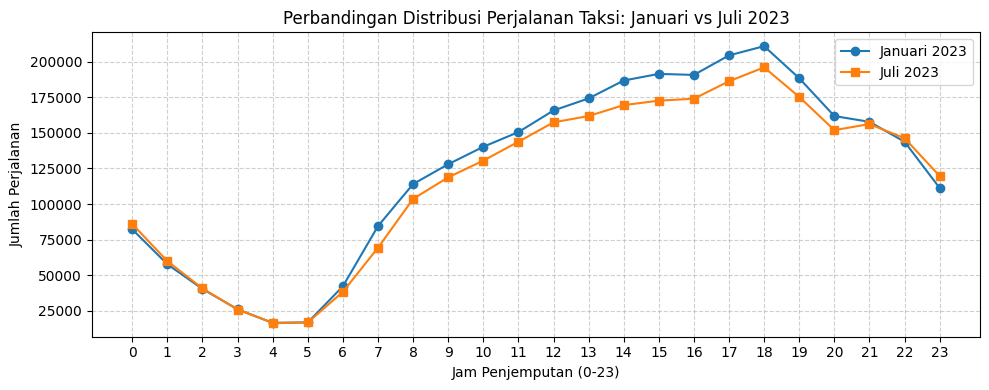

In [66]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(perbandingan["jam"], perbandingan["jumlah_perjalanan_januari"], marker='o', label='Januari 2023')
ax.plot(perbandingan["jam"], perbandingan["jumlah_perjalanan_juli"], marker='s', label='Juli 2023')

ax.set_xlabel("Jam Penjemputan (0-23)")
ax.set_ylabel("Jumlah Perjalanan")
ax.set_title("Perbandingan Distribusi Perjalanan Taksi: Januari vs Juli 2023")
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/perbandingan_jan_jul.png", dpi=150)
plt.show()